# Poisson (Owen - Sam)

In [2]:
%pip install caas-jupyter-tools

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement caas-jupyter-tools (from versions: none)
ERROR: No matching distribution found for caas-jupyter-tools


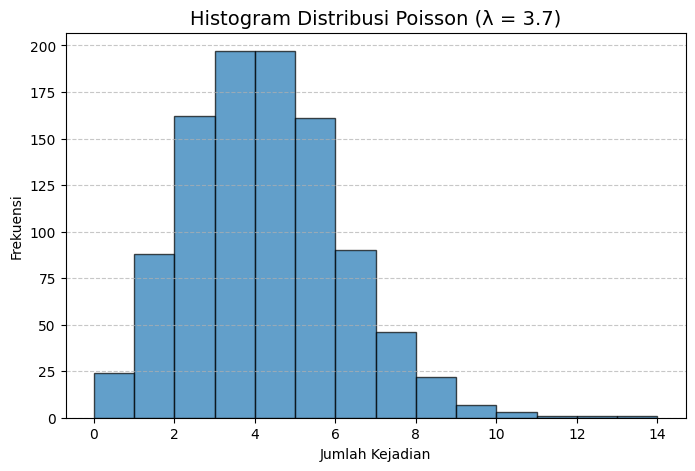

count    1000.000000
mean        3.763000
std         1.931984
min         0.000000
25%         2.000000
50%         4.000000
75%         5.000000
max        13.000000
Name: Jumlah Kejadian, dtype: float64

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameter lambda (rata-rata kejadian)
lam = 3.7  
n = 1000  

# Generate data acak dari distribusi Poisson
data = np.random.poisson(lam, n)
df = pd.DataFrame(data, columns=["Jumlah Kejadian"])

# Ringkasan statistik
summary = df["Jumlah Kejadian"].describe()

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(df["Jumlah Kejadian"], bins=range(0, max(data)+2), edgecolor='black', alpha=0.7)
plt.title("Histogram Distribusi Poisson (λ = 3.7)", fontsize=14)
plt.xlabel("Jumlah Kejadian")
plt.ylabel("Frekuensi")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

summary


In [129]:
# rata-rata 5 kredit motor disetujui per hari, 100 hari pengamatan
kredit_motor = np.random.poisson(lam=5, size=365)

print("\nFinance - Kredit Motor")
print("Rata-rata:", kredit_motor.mean())
print("Varians:", kredit_motor.var())



Finance - Kredit Motor
Rata-rata: 4.936986301369863
Varians: 5.067262150497279


   Hari  Jumlah_Kredit
0     1              7
1     2              5
2     3              4
3     4              8
4     5              4

Statistik Distribusi Kredit Motor:
Rata-rata kredit motor (Mean): 4.94
Varians kredit motor: 5.07


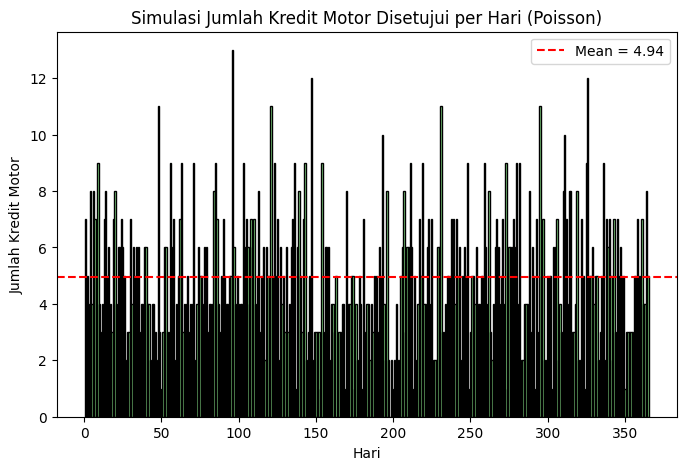

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set parameter Poisson
lam = 5   # rata-rata kredit motor per hari
days = 365  # periode waktu (365 hari)

# Generate data
np.random.seed(123)  # supaya reproducible
credits = np.random.poisson(lam=lam, size=days)

# Buat dataframe
df = pd.DataFrame({
    "Hari": np.arange(1, days+1),
    "Jumlah_Kredit": credits
})

print(df.head())

# Hitung statistik
mean = np.mean(credits)
var = np.var(credits, ddof=0)

print("\nStatistik Distribusi Kredit Motor:")
print(f"Rata-rata kredit motor (Mean): {mean:.2f}")
print(f"Varians kredit motor: {var:.2f}")

# Visualisasi
plt.figure(figsize=(8,5))
plt.bar(df["Hari"], df["Jumlah_Kredit"], color="lightgreen", edgecolor="black")
plt.axhline(mean, color="red", linestyle="--", label=f"Mean = {mean:.2f}")
plt.title("Simulasi Jumlah Kredit Motor Disetujui per Hari (Poisson)")
plt.xlabel("Hari")
plt.ylabel("Jumlah Kredit Motor")
plt.legend()
plt.show()


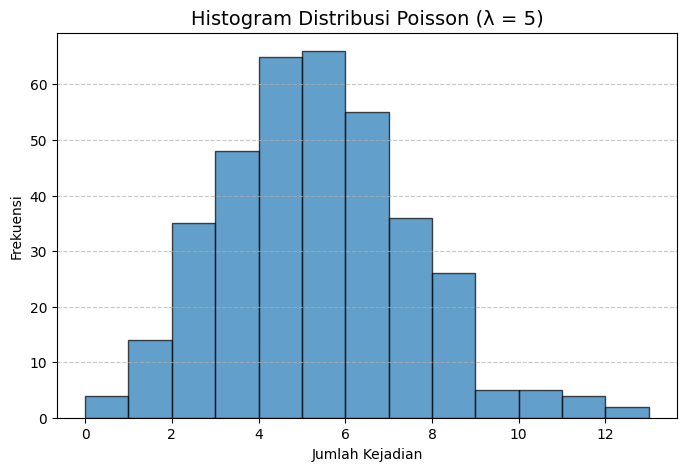

count    365.000000
mean       4.852055
std        2.203899
min        0.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       12.000000
Name: Jumlah Kejadian, dtype: float64

In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameter lambda (rata-rata kejadian)
lam = 5  
n = 365  

# Generate data acak dari distribusi Poisson
data = np.random.poisson(lam, n)
df = pd.DataFrame(data, columns=["Jumlah Kejadian"])

# Ringkasan statistik
summary = df["Jumlah Kejadian"].describe()

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(df["Jumlah Kejadian"], bins=range(0, max(data)+2), edgecolor='black', alpha=0.7)
plt.title("Histogram Distribusi Poisson (λ = 5)", fontsize=14)
plt.xlabel("Jumlah Kejadian")
plt.ylabel("Frekuensi")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

summary


In [161]:
lam_hat = df["Jumlah_Kredit"].mean()
print("Estimasi λ:", lam_hat)


Estimasi λ: 4.936986301369863


In [103]:
from scipy.stats import poisson

prob_3 = poisson.pmf(3, mu=lam_hat)
print("Probabilitas 3 kredit motor dalam sehari: {:.2f}%".format(prob_3 * 100))


Probabilitas 3 kredit motor dalam sehari: 14.39%


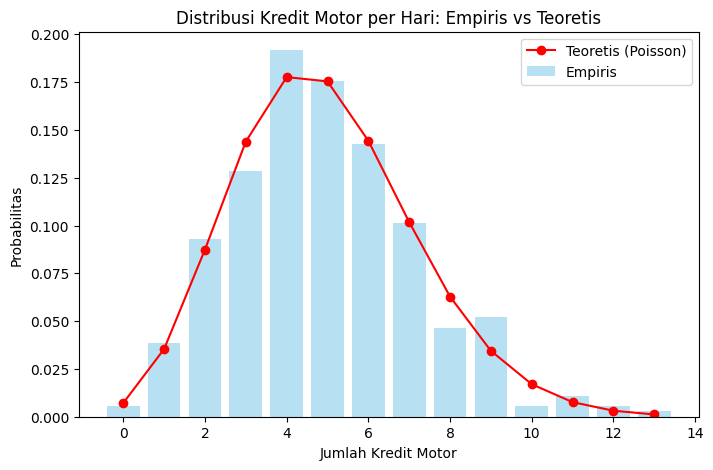

In [104]:
# Hitung distribusi frekuensi empiris
emp_counts = df["Jumlah_Kredit"].value_counts().sort_index()
emp_probs = emp_counts / emp_counts.sum()

# Distribusi teoretis Poisson
k_vals = np.arange(emp_counts.index.min(), emp_counts.index.max()+1)
theo_probs = poisson.pmf(k_vals, mu=lam_hat)

# Plot perbandingan
plt.figure(figsize=(8,5))
plt.bar(emp_counts.index, emp_probs, alpha=0.6, color="skyblue", label="Empiris")
plt.plot(k_vals, theo_probs, "ro-", label="Teoretis (Poisson)")
plt.title("Distribusi Kredit Motor per Hari: Empiris vs Teoretis")
plt.xlabel("Jumlah Kredit Motor")
plt.ylabel("Probabilitas")
plt.legend()
plt.show()


In [106]:
# Distribusi probabilitas prediksi
x = np.arange(0, 10)  # jumlah kredit 0 s/d 9
prediksi = poisson.pmf(x, mu=lam_hat) * 100  # dalam persen

pred_df = pd.DataFrame({
    "x (jumlah kredit)": x,
    "Probabilitas (%)": prediksi
})
print(pred_df)


   x (jumlah kredit)  Probabilitas (%)
0                  0          0.717619
1                  1          3.542877
2                  2          8.745566
3                  3         14.392247
4                  4         17.763582
5                  5         17.539712
6                  6         14.432220
7                  7         10.178810
8                  8          6.281581
9                  9          3.445786


   Hari  Jumlah_Kredit  Weekend  Promo
0     1              7    False      0
1     2              5    False      1
2     3              4    False      1
3     4              8    False      0
4     5              4    False      0


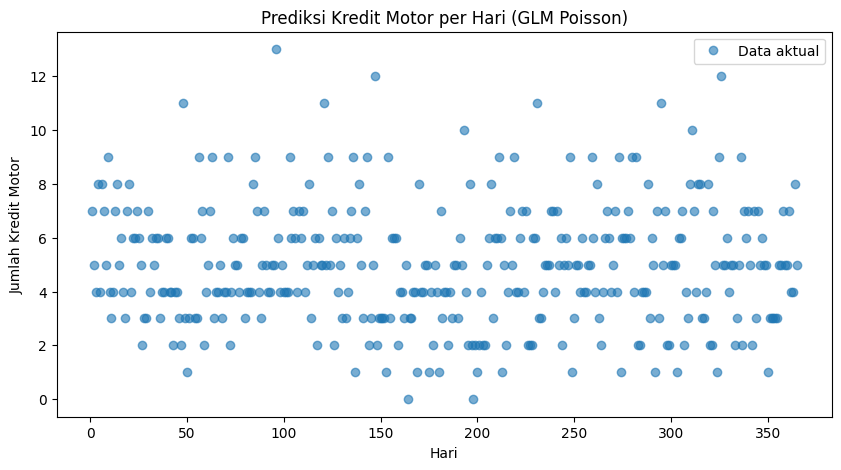

In [137]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# ==== 1. Generate data (sama seperti sebelumnya) ====
lam = 5   # rata-rata kredit motor per hari
days = 365  # periode waktu (365 hari)
np.random.seed(123)
credits = np.random.poisson(lam=lam, size=days)

df = pd.DataFrame({
    "Hari": np.arange(1, days+1),
    "Jumlah_Kredit": credits
})

# ==== 2. Tambah variabel prediktor ====
# Weekday vs Weekend (anggap tiap 7 hari, hari ke-6 dan 7 = weekend)
df["Weekend"] = df["Hari"] % 7 >= 6

# Promo (acak, 30% hari ada promo)
np.random.seed(42)
df["Promo"] = np.random.choice([0, 1], size=days, p=[0.7, 0.3])

print(df.head())

# # ==== 3. Fit model GLM Poisson ====
# model = smf.glm(
#     formula="Jumlah_Kredit ~ Weekend + Promo",
#     data=df,
#     family=sm.families.Poisson()
# ).fit()

# print("\n=== Ringkasan Model Poisson Regression ===")
# print(model.summary())

# # ==== 4. Prediksi jumlah kredit per hari ====
# df["Prediksi"] = model.predict(df)

# ==== 5. Visualisasi ====
plt.figure(figsize=(10,5))
plt.plot(df["Hari"], df["Jumlah_Kredit"], "o", label="Data aktual", alpha=0.6)
# plt.plot(df["Hari"], df["Prediksi"], "r-", label="Prediksi (GLM Poisson)")
plt.xlabel("Hari")
plt.ylabel("Jumlah Kredit Motor")
plt.title("Prediksi Kredit Motor per Hari (GLM Poisson)")
plt.legend()
plt.show()


In [60]:
df.columns

Index(['Hari', 'Jumlah_Kredit', 'Weekend', 'Promo'], dtype='object')

In [158]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# ==== 1. Generate data ====
lam = 5
days = 365
np.random.seed(123)
credits = np.random.poisson(lam=lam, size=days)

df = pd.DataFrame({
    "Hari": np.arange(1, days+1),
    "Jumlah_Kredit": credits
})

# Variabel prediktor
df["Weekend"] = (df["Hari"] % 7 >= 6).astype(int)
np.random.seed(42)
df["Promo"] = np.random.choice([0,1], size=days, p=[0.7,0.3])

# ==== 2. Split data: 95% train, 5% test ====
train_df, test_df = train_test_split(df, test_size=0.05, random_state=42)

X_train = train_df[["Weekend", "Promo"]]
y_train = train_df["Jumlah_Kredit"]

X_test = test_df[["Weekend", "Promo"]]
y_test = test_df["Jumlah_Kredit"]

# ==== 3. Fit model GLM Poisson sklearn ====
model = PoissonRegressor(alpha=0, max_iter=1000)
model.fit(X_train, y_train)

# ==== 4. Prediksi ====
train_df["Prediksi"] = model.predict(X_train)
test_df["Prediksi"] = model.predict(X_test)

# ==== 5. Evaluasi ====
mse_train = mean_squared_error(y_train, train_df["Prediksi"])
mse_test = mean_squared_error(y_test, test_df["Prediksi"])
print(f"MSE Train: {mse_train:.3f}, MSE Test: {mse_test:.3f}")

# ==== 6. Koefisien model ====
coef = pd.DataFrame({
    "Prediktor": ["Intercept"] + list(X_train.columns),
    "Koefisien": np.concatenate(([model.intercept_], model.coef_))
})
coef["Exp(Koef)"] = np.exp(coef["Koefisien"])  # efek multiplicative terhadap rata-rata
print("\n=== Koefisien Model ===")
print(coef)

# # ==== 7. Visualisasi ====
# plt.figure(figsize=(10,5))
# plt.plot(df["Hari"], df["Jumlah_Kredit"], "o", alpha=0.6, label="Data Aktual")
# plt.plot(train_df["Hari"], train_df["Prediksi"], "r-", label="Prediksi Train")
# plt.plot(test_df["Hari"], test_df["Prediksi"], "g*", markersize=12, label="Prediksi Test")
# plt.xlabel("Hari")
# plt.ylabel("Jumlah Kredit Motor")
# plt.title("Prediksi Kredit Motor per Hari (GLM Poisson sklearn) dengan Weekend & Promo")
# plt.legend()
# plt.show()


MSE Train: 5.134, MSE Test: 3.385

=== Koefisien Model ===
   Prediktor  Koefisien  Exp(Koef)
0  Intercept   1.561782   4.767311
1    Weekend   0.052080   1.053460
2      Promo   0.069484   1.071955


In [125]:
import statsmodels.api as sm

X = df[['Weekend', 'Promo']]
y = df['Jumlah_Kredit']
X = sm.add_constant(X)  # tambahkan intercept

poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()
print(poisson_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:          Jumlah_Kredit   No. Observations:                  365
Model:                            GLM   Df Residuals:                      362
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -804.13
Date:                Fri, 26 Sep 2025   Deviance:                       385.97
Time:                        10:37:23   Pearson chi2:                     373.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.005310
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5718      0.030     51.680      0.0

In [159]:
import numpy as np
import pandas as pd

# ==== 1. Generate data ====
lam = 5           # rata-rata kredit per hari
days = 365        # jumlah hari
np.random.seed(123)
credits = np.random.poisson(lam=lam, size=days)

df = pd.DataFrame({
    "Hari": np.arange(1, days+1),
    "Jumlah_Kredit": credits
})

# ==== 2. Tambah prediktor ====
# Weekend (0=weekday, 1=weekend)
df["Weekend"] = (df["Hari"] % 7 >= 6).astype(int)

# Promo (0=tidak ada, 1=ada promo)
np.random.seed(42)
df["Promo"] = np.random.choice([0,1], size=days, p=[0.7,0.3])

# ==== 3. Cek data ====
print(df.head(10))


   Hari  Jumlah_Kredit  Weekend  Promo
0     1              7        0      0
1     2              5        0      1
2     3              4        0      1
3     4              8        0      0
4     5              4        0      0
5     6              8        1      0
6     7              7        0      0
7     8              5        0      1
8     9              9        0      0
9    10              4        0      1


In [160]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_squared_error

# ==== 1. Generate data ====
lam = 5
days = 365
np.random.seed(123)
credits = np.random.poisson(lam=lam, size=days)

df = pd.DataFrame({
    "Hari": np.arange(1, days+1),
    "Jumlah_Kredit": credits
})

# Variabel prediktor
df["Weekend"] = (df["Hari"] % 7 >= 6).astype(int)
np.random.seed(42)
df["Promo"] = np.random.choice([0,1], size=days, p=[0.7,0.3])

# ==== 2. Randomize data ====
df = df.sample(frac=1, random_state=101).reset_index(drop=True)

# ==== 3. Split 95% untuk train+test internal ====
n_train_test = int(len(df) * 0.95)
train_test_df = df.iloc[:n_train_test]

# ==== 4. Split train_test_df menjadi train & internal test ====
train_df, test_df = train_test_split(train_test_df, test_size=0.1, random_state=42)

# ==== 5. Prediktor & target ====
X_train = train_df[["Weekend", "Promo"]]
y_train = train_df["Jumlah_Kredit"]

X_test = test_df[["Weekend", "Promo"]]
y_test = test_df["Jumlah_Kredit"]

# ==== 6. Fit Poisson GLM (sklearn) ====
model = PoissonRegressor(alpha=0, max_iter=300)
model.fit(X_train, y_train)

# ==== 7. Prediksi untuk train & test internal ====
train_df["Prediksi"] = model.predict(X_train)
test_df["Prediksi"] = model.predict(X_test)

# ==== 8. Prediksi dalam log scale (opsional) ====
train_df["Log_Prediksi"] = np.log(train_df["Prediksi"])
test_df["Log_Prediksi"] = np.log(test_df["Prediksi"])

# ==== 9. Evaluasi sederhana: MSE ====
mse_train = mean_squared_error(y_train, train_df["Prediksi"])
mse_test = mean_squared_error(y_test, test_df["Prediksi"])

print(f"MSE Train: {mse_train:.3f}")
print(f"MSE Test Internal: {mse_test:.3f}")

# ==== 10. Contoh prediksi ====
print("\nContoh 5 baris prediksi Train:")
print(train_df[["Hari", "Jumlah_Kredit", "Prediksi", "Log_Prediksi"]].head())

print("\nContoh 5 baris prediksi Test Internal:")
print(test_df[["Hari", "Jumlah_Kredit", "Prediksi", "Log_Prediksi"]].head())

# ==== 11. Koefisien model (interpretasi GLM Poisson) ====
coef_df = pd.DataFrame({
    "Prediktor": ["Intercept", "Weekend", "Promo"],
    "Koefisien": np.concatenate(([model.intercept_], model.coef_)),
    "Exp(Koef)": np.exp(np.concatenate(([model.intercept_], model.coef_)))
})
print("\n=== Koefisien Model ===")
print(coef_df)


MSE Train: 5.086
MSE Test Internal: 5.031

Contoh 5 baris prediksi Train:
     Hari  Jumlah_Kredit  Prediksi  Log_Prediksi
94     91              5  4.804721      1.569599
343    60              4  4.804721      1.569599
194   259              9  4.804721      1.569599
5     172              4  4.804721      1.569599
211   222              6  4.804721      1.569599

Contoh 5 baris prediksi Test Internal:
     Hari  Jumlah_Kredit  Prediksi  Log_Prediksi
108   170              8  4.804721      1.569599
158    86              7  4.804721      1.569599
278   132              3  5.083057      1.625913
209    81              4  4.973505      1.604125
320     1              7  4.804721      1.569599

=== Koefisien Model ===
   Prediktor  Koefisien  Exp(Koef)
0  Intercept   1.569599   4.804721
1    Weekend   0.056314   1.057930
2      Promo   0.034526   1.035129


In [149]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# ==== 1. Generate data ====
lam = 5
days = 365
np.random.seed(123)
credits = np.random.poisson(lam=lam, size=days)

df = pd.DataFrame({
    "Hari": np.arange(1, days+1),
    "Jumlah_Kredit": credits
})

# Variabel prediktor
df["Weekend"] = (df["Hari"] % 7 >= 6).astype(int)
np.random.seed(42)
df["Promo"] = np.random.choice([0,1], size=days, p=[0.7,0.3])

# ==== 2. Randomize data ====
df = df.sample(frac=1, random_state=101).reset_index(drop=True)

# ==== 3. Split 95% untuk train+test internal, 5% untuk validation ====
n_train_test = int(len(df) * 0.95)
train_test_df = df.iloc[:n_train_test]
validation_df = df.iloc[n_train_test:]

# ==== 4. Split train_test_df menjadi train & internal test ====
train_df, test_df = train_test_split(train_test_df, test_size=0.2, random_state=42)

# ==== 5. Prediktor & target ====
X_train = train_df[["Weekend", "Promo"]]
y_train = train_df["Jumlah_Kredit"]

X_test = test_df[["Weekend", "Promo"]]
y_test = test_df["Jumlah_Kredit"]

# ==== 6. Fit model Poisson ====
model = PoissonRegressor(alpha=0, max_iter=1000)
model.fit(X_train, y_train)

# ==== 7. Prediksi desimal untuk train & test internal ====
train_df["Prediksi"] = model.predict(X_train)
test_df["Prediksi"] = model.predict(X_test)

# ==== 8. Prediksi integer dengan sampling Poisson ====
np.random.seed(123)  # agar hasil reproducible
train_df["Prediksi_Rounded"] = train_df["Prediksi"].round().astype(int)
test_df["Prediksi_Rounded"] = test_df["Prediksi"].round().astype(int)


# ==== 9. Evaluasi sederhana: MSE (desimal) ====
mse_train = mean_squared_error(y_train, train_df["Prediksi"])
mse_test = mean_squared_error(y_test, test_df["Prediksi"])


r2_train = r2_score(y_train, train_df["Prediksi"])
r2_test = r2_score(y_test, test_df["Prediksi"])

# ==== 10. Print hasil ====
print(f"Jumlah data total: {len(df)}")
print(f"Jumlah data train: {len(train_df)}")
print(f"Jumlah data test internal: {len(test_df)}")
print(f"Jumlah data validasi: {len(validation_df)}\n")

print(f"MSE Train: {mse_train:.3f}")
print(f"MSE Test Internal: {mse_test:.3f}")
print(f"R2 Train: {r2_train:.3f}")
print(f"R2 Test Internal: {r2_test:.3f}\n")

# ==== 10. Contoh prediksi ====
print("\nContoh 5 baris prediksi Train:")
print(train_df[["Hari", "Jumlah_Kredit", "Prediksi", "Prediksi_Rounded"]].head())

print("\nContoh 5 baris prediksi Test Internal:")
print(test_df[["Hari", "Jumlah_Kredit", "Prediksi", "Prediksi_Rounded"]].head())




Jumlah data total: 365
Jumlah data train: 276
Jumlah data test internal: 70
Jumlah data validasi: 19

MSE Train: 5.183
MSE Test Internal: 4.705
R2 Train: 0.001
R2 Test Internal: -0.044


Contoh 5 baris prediksi Train:
     Hari  Jumlah_Kredit  Prediksi  Prediksi_Rounded
116   213              1  4.770606                 5
7     207              8  4.770606                 5
153   257              5  4.926330                 5
101   343              7  4.770606                 5
307   277              6  4.926330                 5

Contoh 5 baris prediksi Test Internal:
     Hari  Jumlah_Kredit  Prediksi  Prediksi_Rounded
108   170              8  4.770606                 5
158    86              7  4.770606                 5
278   132              3  4.894415                 5
209    81              4  4.926330                 5
320     1              7  4.770606                 5


In [166]:
# === 3. Split 95% untuk train+test internal, 5% untuk validation ===
n_train_test = int(len(df) * 0.95)
train_test_df = df.iloc[:n_train_test]
validation_df = df.iloc[n_train_test:].copy()  # <-- tambahkan .copy()


In [94]:
validation_df.columns

Index(['Hari', 'Jumlah_Kredit', 'Weekend', 'Promo', 'Kategori'], dtype='object')

In [167]:
# Prediktor & target untuk validation
X_val = validation_df[["Weekend", "Promo"]]
y_val = validation_df["Jumlah_Kredit"]

# Prediksi desimal
validation_df["Prediksi"] = model.predict(X_val)

# Prediksi integer (dengan pembulatan)
validation_df["Prediksi_Rounded"] = validation_df["Prediksi"].round().astype(int)

# Evaluasi MSE untuk validation
mse_val = mean_squared_error(y_val, validation_df["Prediksi"])
print(f"MSE Validation: {mse_val:.3f}")

# Contoh 5 baris prediksi validation
print("\nContoh 5 baris prediksi Validation:")
print(validation_df[["Hari", "Jumlah_Kredit", "Prediksi", "Prediksi_Rounded"]].head(10))


MSE Validation: 4.538

Contoh 5 baris prediksi Validation:
     Hari  Jumlah_Kredit  Prediksi  Prediksi_Rounded
346   340              7  4.804721                 5
347    50              1  4.804721                 5
348   358              7  4.804721                 5
349     6              8  5.083057                 5
350   111              4  5.083057                 5
351   193             10  4.973505                 5
352   221              4  4.804721                 5
353   317              3  4.804721                 5
354   246              6  4.973505                 5
355   361              7  4.804721                 5


In [168]:
from sklearn.metrics import mean_squared_error, r2_score

# Prediktor & target untuk validation
X_val = validation_df[["Weekend", "Promo"]]
y_val = validation_df["Jumlah_Kredit"]

# Prediksi desimal
validation_df["Prediksi"] = model.predict(X_val)

# Prediksi integer (dengan pembulatan)
validation_df["Prediksi_Rounded"] = validation_df["Prediksi"].round().astype(int)

# Evaluasi MSE untuk validation
mse_val = mean_squared_error(y_val, validation_df["Prediksi"])
print(f"MSE Validation: {mse_val:.3f}")

# Evaluasi R^2 untuk validation
r2_val = r2_score(y_val, validation_df["Prediksi"])
print(f"R² Validation: {r2_val:.3f}")

# Contoh 5 baris prediksi validation
print("\nContoh 5 baris prediksi Validation:")
print(validation_df[["Hari", "Jumlah_Kredit", "Prediksi", "Prediksi_Rounded"]].head(10))


MSE Validation: 4.538
R² Validation: 0.020

Contoh 5 baris prediksi Validation:
     Hari  Jumlah_Kredit  Prediksi  Prediksi_Rounded
346   340              7  4.804721                 5
347    50              1  4.804721                 5
348   358              7  4.804721                 5
349     6              8  5.083057                 5
350   111              4  5.083057                 5
351   193             10  4.973505                 5
352   221              4  4.804721                 5
353   317              3  4.804721                 5
354   246              6  4.973505                 5
355   361              7  4.804721                 5


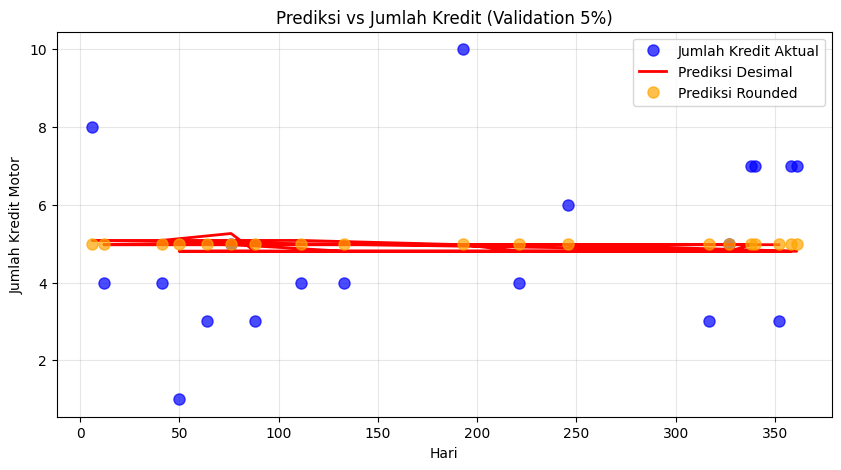

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Jumlah Kredit Aktual (Biru)
plt.plot(validation_df["Hari"], validation_df["Jumlah_Kredit"], 'bo', markersize=8, alpha=0.7, label="Jumlah Kredit Aktual")

# Prediksi Desimal (Merah)
plt.plot(validation_df["Hari"], validation_df["Prediksi"], 'r-', linewidth=2, label="Prediksi Desimal")

# Prediksi Rounded (Oranye)
plt.plot(validation_df["Hari"], validation_df["Prediksi_Rounded"], 'o', color='orange', markersize=8, alpha=0.7, label="Prediksi Rounded")

plt.xlabel("Hari")
plt.ylabel("Jumlah Kredit Motor")
plt.title("Prediksi vs Jumlah Kredit (Validation 5%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [121]:
# Buat kolom kombinasi
validation_df["Kategori"] = validation_df.apply(
    lambda row: f"Weekend={row['Weekend']}, Promo={row['Promo']}", axis=1
)


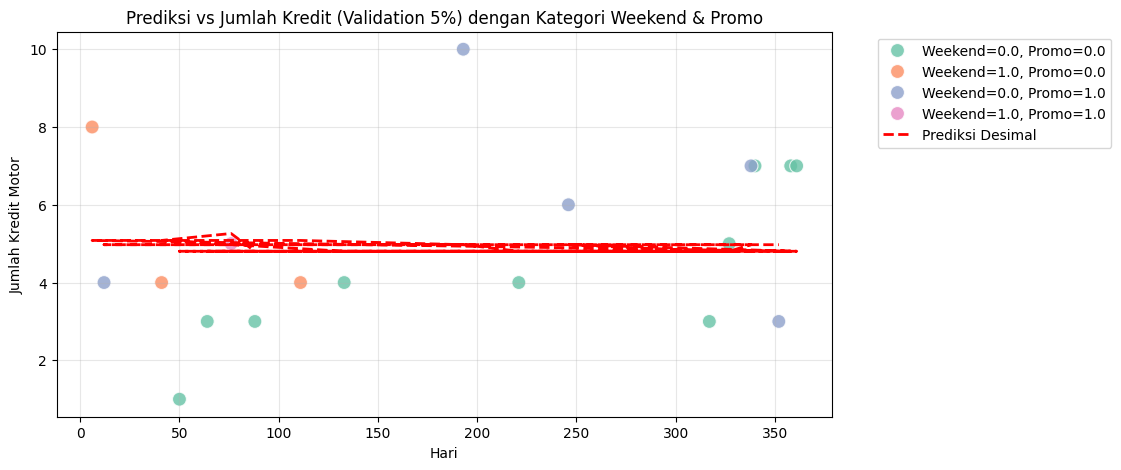

In [122]:
import seaborn as sns
plt.figure(figsize=(10,5))

# Plot dengan seaborn scatterplot
sns.scatterplot(
    data=validation_df,
    x="Hari",
    y="Jumlah_Kredit",
    hue="Kategori",
    s=100,  # ukuran titik
    palette="Set2",
    alpha=0.8
)

# Plot Prediksi Desimal sebagai garis
plt.plot(validation_df["Hari"], validation_df["Prediksi"], 'r--', linewidth=2, label="Prediksi Desimal")

plt.xlabel("Hari")
plt.ylabel("Jumlah Kredit Motor")
plt.title("Prediksi vs Jumlah Kredit (Validation 5%) dengan Kategori Weekend & Promo")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()


In [144]:
# ==== 11. Prediksi hari berikutnya ==== 

# Ambil fitur hari berikutnya dari dataset (contoh: hari setelah terakhir di train_test_df)
hari_terakhir = df["Hari"].max()
next_day = hari_terakhir + 1

# Tentukan fitur untuk hari berikutnya
weekend_next = int(next_day % 7 >= 6)
# Misal promo random seperti distribusi sebelumnya
np.random.seed(2025)
promo_next = np.random.choice([0,1], p=[0.7,0.3])

X_next = pd.DataFrame({"Weekend":[weekend_next], "Promo":[promo_next]})

# Prediksi
prediksi_next = model.predict(X_next)[0]
prediksi_next_rounded = int(round(prediksi_next))

print(f"Hari ke depan: {next_day}")
print(f"Prediksi jumlah kredit (desimal): {prediksi_next:.2f}")
print(f"Prediksi jumlah kredit (integer): {prediksi_next_rounded}")


Hari ke depan: 366
Prediksi jumlah kredit (desimal): 4.77
Prediksi jumlah kredit (integer): 5
